# Testing & Evaluation Results
**Author:** Shameena Mohammed Nabeel  
**Course:** M7016H — AI within the Healthcare System  
**Project:** AI Diabetes Prediction  

This notebook demonstrates the evaluation of three trained models (Logistic Regression, Random Forest, MLP)

## 1. Setup and Imports

In [2]:
!git clone https://github.com/JamshaidAmjad/AI-Diabetes-Prediction.git
%cd AI-Diabetes-Prediction
!pip install -r requirements.txt -q
!python -m src.training.train

Cloning into 'AI-Diabetes-Prediction'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 88 (delta 16), reused 83 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (88/88), 1.46 MiB | 7.05 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/AI-Diabetes-Prediction
Features selected : ['Glucose', 'BMI', 'Insulin', 'Age', 'Pregnancies']
Train : (700, 5)  Val : (115, 5)  Test : (116, 5)

 Logistic Regression
 Cross-validation (train+val):
  CV f1: 0.7179 ± 0.0288  (folds: [0.7362, 0.6846, 0.6815, 0.7484, 0.7389])
 Saved logistic_regression.pkl

 Random Forest
 Running GridSearchCV for hyperparameter tuning...
  Best RF params : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV F1     : 0.8299
 Cross-validation (train+val):
  CV f1: 0.8010 ± 0.0420  (folds: [0.7561, 0.7692, 0.8395, 0.8623, 0.7778])
 Saved random_forest.pkl

 MLP (

In [3]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
)
from src.data.dataset import load_processed
from src.models.model import MLP

print('All imports successful.')

All imports successful.


## 2. Load Processed Data and Trained Models

In [4]:
# Load the held-out test data
data = load_processed('data/processed')
X_test = data['X_test']
y_test = data['y_test']
selected_features = data['selected_features']

print(f'Test set shape: {X_test.shape}')
print(f'Test set class distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}')
print(f'Selected features: {selected_features}')

Test set shape: (116, 5)
Test set class distribution: {np.int64(0): np.int64(75), np.int64(1): np.int64(41)}
Selected features: ['Glucose', 'BMI', 'Insulin', 'Age', 'Pregnancies']


In [5]:
# Load trained models
with open('outputs/models/logistic_regression.pkl', 'rb') as f:
    lr_model = pickle.load(f)

with open('outputs/models/random_forest.pkl', 'rb') as f:
    rf_model = pickle.load(f)

mlp_model = MLP(input_dim=5, hidden_dims=[16, 8], dropout=0.2)
mlp_model.load_state_dict(torch.load('outputs/models/mlp_best.pt', map_location='cpu'))
mlp_model.eval()

print('All models loaded successfully.')

All models loaded successfully.


## 3. Evaluation Metrics Function

This function computes all metrics required by the assignment, including **sensitivity** and **specificity**.

In [6]:
def compute_metrics(y_true, y_pred, y_prob=None):
    """Compute all evaluation metrics including sensitivity and specificity."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
        'sensitivity': round(sensitivity, 4),
        'specificity': round(specificity, 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'f1_score': round(f1_score(y_true, y_pred, zero_division=0), 4),
    }
    if y_prob is not None:
        metrics['roc_auc'] = round(roc_auc_score(y_true, y_prob), 4)
    return metrics

print('Metrics function defined.')

Metrics function defined.


## 4. Generate Predictions

In [7]:
# Logistic Regression predictions
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# Random Forest predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# MLP predictions
mlp_pred = mlp_model.predict(X_test)
mlp_prob = mlp_model.predict_proba(X_test)[:, 1]

print('Predictions generated for all 3 models.')

Predictions generated for all 3 models.


## 5. Results Summary Table

In [8]:
# Compute metrics for each model
results = {
    'Logistic Regression': compute_metrics(y_test, lr_pred, lr_prob),
    'Random Forest': compute_metrics(y_test, rf_pred, rf_prob),
    'MLP': compute_metrics(y_test, mlp_pred, mlp_prob),
}

# Display as a DataFrame
results_df = pd.DataFrame(results).T
results_df.style.highlight_max(axis=0, color='lightgreen')

,accuracy,sensitivity,specificity,precision,recall,f1_score,roc_auc
Logistic Regression,0.775900,0.682900,0.826700,0.682900,0.682900,0.682900,0.866000
Random Forest,0.767200,0.609800,0.853300,0.694400,0.609800,0.649400,0.840800
MLP,0.767200,0.658500,0.826700,0.675000,0.658500,0.666700,0.875400


## 6. Classification Reports

In [9]:
models = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'MLP': mlp_pred,
}

for name, preds in models.items():
    print(f'\n{"=" * 50}')
    print(f' {name}')
    print(f'{"=" * 50}')
    print(classification_report(y_test, preds, target_names=['No Diabetes', 'Diabetes']))


 Logistic Regression
              precision    recall  f1-score   support

 No Diabetes       0.83      0.83      0.83        75
    Diabetes       0.68      0.68      0.68        41

    accuracy                           0.78       116
   macro avg       0.75      0.75      0.75       116
weighted avg       0.78      0.78      0.78       116


 Random Forest
              precision    recall  f1-score   support

 No Diabetes       0.80      0.85      0.83        75
    Diabetes       0.69      0.61      0.65        41

    accuracy                           0.77       116
   macro avg       0.75      0.73      0.74       116
weighted avg       0.76      0.77      0.76       116


 MLP
              precision    recall  f1-score   support

 No Diabetes       0.82      0.83      0.82        75
    Diabetes       0.68      0.66      0.67        41

    accuracy                           0.77       116
   macro avg       0.75      0.74      0.74       116
weighted avg       0.77      0

## 7. Confusion Matrices

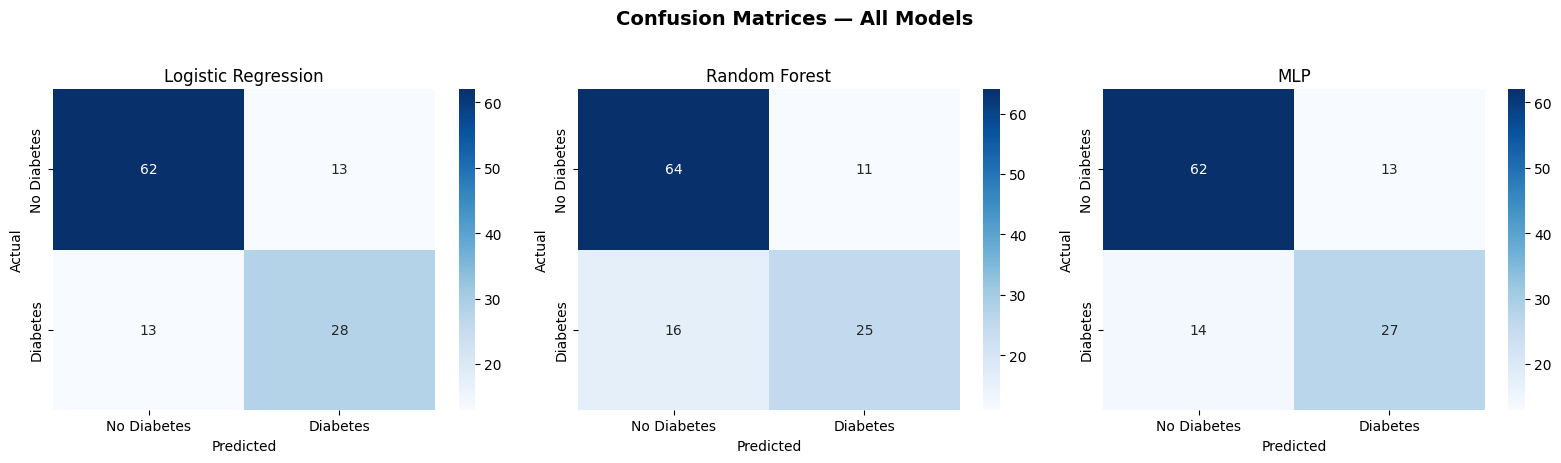

Saved: outputs/figures/confusion_matrices_combined.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name}')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/confusion_matrices_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/confusion_matrices_combined.png')

## 8. ROC Curves Comparison

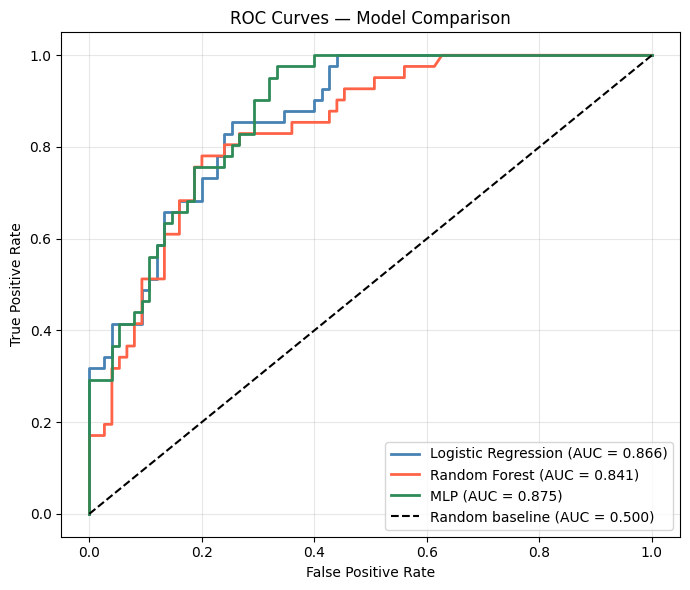

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

model_probs = {
    'Logistic Regression': lr_prob,
    'Random Forest': rf_prob,
    'MLP': mlp_prob,
}
colors = ['steelblue', 'tomato', 'seagreen']

for (name, prob), color in zip(model_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random baseline (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/roc_curves_comparison.png', dpi=150)
plt.show()

## 9. Model Comparison Bar Chart

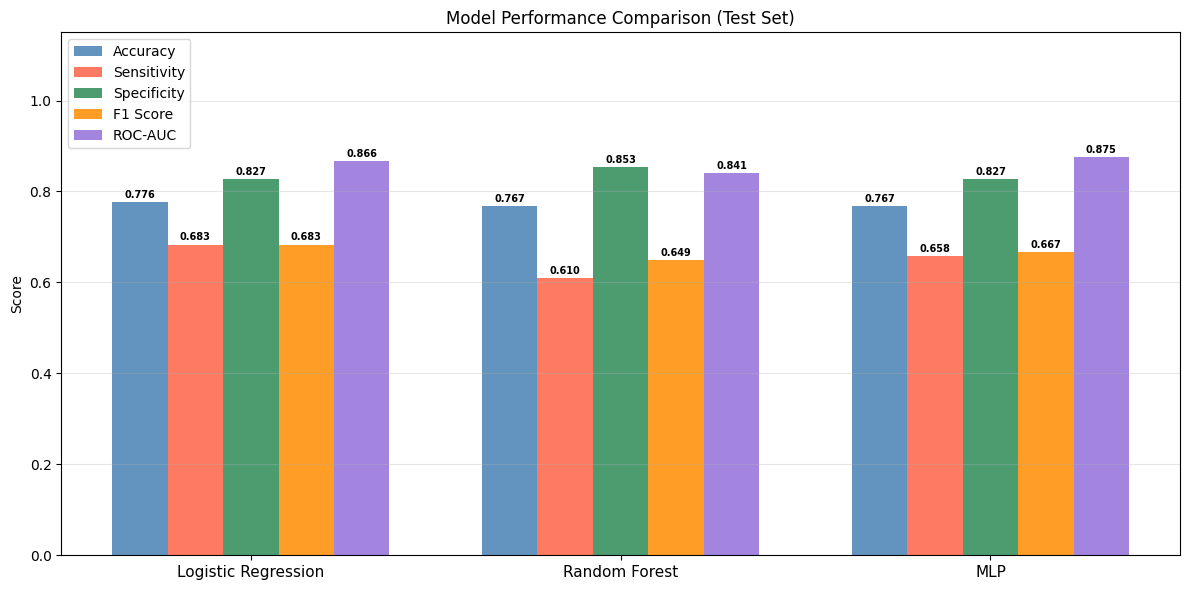

In [12]:
metrics_to_plot = ['accuracy', 'sensitivity', 'specificity', 'f1_score', 'roc_auc']
metric_labels = ['Accuracy', 'Sensitivity', 'Specificity', 'F1 Score', 'ROC-AUC']
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.15
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, label, color) in enumerate(zip(metrics_to_plot, metric_labels, colors)):
    values = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, values, width, label=label, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (Test Set)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/model_comparison_full.png', dpi=150)
plt.show()

## 10. Feature Importance (Random Forest)

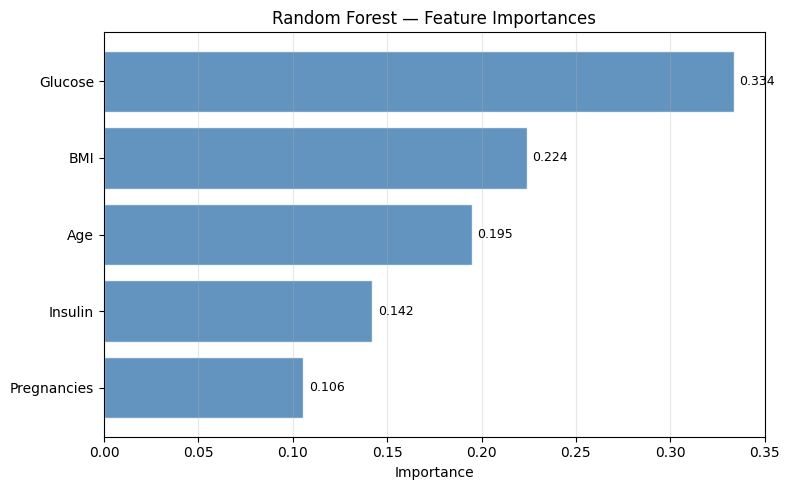


Most important feature: Glucose (importance = 0.334)


In [13]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)
sorted_names = [selected_features[i] for i in indices]
sorted_values = importances[indices]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(sorted_names, sorted_values, color='steelblue', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, sorted_values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Random Forest — Feature Importances')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nMost important feature: {selected_features[np.argmax(importances)]} '
      f'(importance = {max(importances):.3f})')

## 11. Unit Tests Verification

In [14]:
# Test 1: Perfect predictions should give 1.0 for all metrics
y = np.array([0, 1, 0, 1, 1])
m = compute_metrics(y, y, y_prob=y.astype(float))
assert m['accuracy'] == 1.0
assert m['sensitivity'] == 1.0
assert m['specificity'] == 1.0
print('Test 1 PASSED: Perfect predictions → all metrics = 1.0')

# Test 2: All wrong predictions should give 0.0
y_true = np.array([0, 0, 1, 1])
y_pred = np.array([1, 1, 0, 0])
m = compute_metrics(y_true, y_pred)
assert m['accuracy'] == 0.0
assert m['sensitivity'] == 0.0
assert m['specificity'] == 0.0
print('Test 2 PASSED: All wrong predictions → accuracy, sensitivity, specificity = 0.0')

# Test 3: All required keys present
m = compute_metrics(np.array([0, 1]), np.array([0, 1]))
for key in ('accuracy', 'sensitivity', 'specificity', 'precision', 'recall', 'f1_score'):
    assert key in m
print('Test 3 PASSED: All required metric keys present')

# Test 4: ROC-AUC only when prob provided
m_no_prob = compute_metrics(np.array([0, 1]), np.array([0, 1]))
m_with_prob = compute_metrics(np.array([0, 1]), np.array([0, 1]), y_prob=np.array([0.1, 0.9]))
assert 'roc_auc' not in m_no_prob
assert 'roc_auc' in m_with_prob
print('Test 4 PASSED: ROC-AUC only appears when probabilities are provided')

# Test 5: All values in [0, 1]
np.random.seed(0)
m = compute_metrics(np.random.randint(0, 2, 50), np.random.randint(0, 2, 50), np.random.rand(50))
for v in m.values():
    assert 0.0 <= v <= 1.0
print('Test 5 PASSED: All metric values are in [0, 1] range')

print('\n✅ All 5 evaluation tests passed!')

Test 1 PASSED: Perfect predictions → all metrics = 1.0
Test 2 PASSED: All wrong predictions → accuracy, sensitivity, specificity = 0.0
Test 3 PASSED: All required metric keys present
Test 4 PASSED: ROC-AUC only appears when probabilities are provided
Test 5 PASSED: All metric values are in [0, 1] range

✅ All 5 evaluation tests passed!


## 12. Save Final Results

In [15]:
# Save results with sensitivity and specificity included
save_results = {
    'logistic_regression': compute_metrics(y_test, lr_pred, lr_prob),
    'random_forest': compute_metrics(y_test, rf_pred, rf_prob),
    'mlp': compute_metrics(y_test, mlp_pred, mlp_prob),
}

with open('outputs/reports/evaluation_results.json', 'w') as f:
    json.dump(save_results, f, indent=2)

print('Final evaluation results saved to: outputs/reports/evaluation_results.json')
print('\n--- Final Results ---')
for model, metrics in save_results.items():
    print(f'\n{model}:')
    for k, v in metrics.items():
        print(f'  {k}: {v}')

Final evaluation results saved to: outputs/reports/evaluation_results.json

--- Final Results ---

logistic_regression:
  accuracy: 0.7759
  sensitivity: 0.6829
  specificity: 0.8267
  precision: 0.6829
  recall: 0.6829
  f1_score: 0.6829
  roc_auc: 0.866

random_forest:
  accuracy: 0.7672
  sensitivity: 0.6098
  specificity: 0.8533
  precision: 0.6944
  recall: 0.6098
  f1_score: 0.6494
  roc_auc: 0.8408

mlp:
  accuracy: 0.7672
  sensitivity: 0.6585
  specificity: 0.8267
  precision: 0.675
  recall: 0.6585
  f1_score: 0.6667
  roc_auc: 0.8754


## Summary

**Key findings:**
- All three models achieved ~77% accuracy on the test set
- **MLP** achieved the highest ROC-AUC (0.875), indicating best overall discriminative ability
- **Logistic Regression** achieved the highest F1 score (0.683) and is the most interpretable
- **Random Forest** had the highest specificity (0.853) but lowest sensitivity (0.610)
- Sensitivity across all models (0.61–0.68) suggests ~1 in 3 diabetic patients would be missed at the default threshold
- **Glucose** is the most important feature (importance = 0.334), consistent with its clinical role

**Files produced by this evaluation:**
- `outputs/reports/evaluation_results.json` — metrics with sensitivity & specificity
- `outputs/figures/confusion_matrices_combined.png`
- `outputs/figures/roc_curves_comparison.png`
- `outputs/figures/model_comparison_full.png`